# Total Solar Eclipse — Cinematic Educational Shorts Notebook

This is a **specific-event** notebook for one topic: **a total solar eclipse**.

It generates a polished vertical info video with:

- Sun–Moon–Earth alignment visuals
- umbra and penumbra geometry
- partial-eclipse crescent phase
- totality with corona, stars, and diamond-ring style highlights
- Moon-shadow path across Earth
- viewing-safety and science takeaway scene
- glow typography, lower-third captions, progress bar, and cinematic transitions

**Outputs**

- `Solar_Eclipse_Cinematic_Info_Shorts.mp4`
- `Solar_Eclipse_Cinematic_Storyboard.png`

Run the cells from top to bottom. Start with `DRAFT_MODE = True` for a quick render, then switch it off for a sharper final export.


In [ ]:
# In a fresh Colab/Jupyter environment, uncomment this line:
# %pip install -U numpy pillow imageio imageio-ffmpeg tqdm


In [1]:
from __future__ import annotations

from pathlib import Path
import math
import random
import textwrap
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import imageio.v2 as imageio

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

# ==========================
# Render settings
# ==========================
OUT_DIR = Path("solar_eclipse_cinematic_output")
OUT_DIR.mkdir(exist_ok=True)

DRAFT_MODE = True  # True = faster preview. False = higher quality final render.

if DRAFT_MODE:
    W, H = 540, 960
    FPS = 20
else:
    W, H = 720, 1280
    FPS = 24

VIDEO_SECONDS = 42.0
NFRAMES = int(VIDEO_SECONDS * FPS)

VIDEO_NAME = OUT_DIR / "Solar_Eclipse_Cinematic_Info_Shorts.mp4"
STORYBOARD_NAME = OUT_DIR / "Solar_Eclipse_Cinematic_Storyboard.png"
SEED = 27
random.seed(SEED)
np.random.seed(SEED)

# ==========================
# Specific event script: Total Solar Eclipse
# ==========================
SCENES = [
    {
        "start": 0.0,
        "end": 6.4,
        "kind": "alignment",
        "eyebrow": "RARE ALIGNMENT",
        "title": "TOTAL SOLAR ECLIPSE",
        "caption": "The Moon passes between Earth and the Sun — and the sky begins to change.",
        "stat": "Sun • Moon • Earth",
    },
    {
        "start": 6.4,
        "end": 13.2,
        "kind": "shadow_geometry",
        "eyebrow": "MOON SHADOW",
        "title": "UMBRA + PENUMBRA",
        "caption": "The dark central umbra makes totality. The wider penumbra creates a partial eclipse.",
        "stat": "A moving cone of shadow",
    },
    {
        "start": 13.2,
        "end": 20.0,
        "kind": "partial_phase",
        "eyebrow": "FIRST CONTACT",
        "title": "THE SUN BECOMES A CRESCENT",
        "caption": "Bit by bit, the Moon covers the bright solar disk.",
        "stat": "Partial phase",
    },
    {
        "start": 20.0,
        "end": 28.0,
        "kind": "totality",
        "eyebrow": "TOTALITY",
        "title": "THE CORONA APPEARS",
        "caption": "When the photosphere is hidden, the Sun's faint outer atmosphere becomes visible.",
        "stat": "Day turns to twilight",
    },
    {
        "start": 28.0,
        "end": 35.0,
        "kind": "shadow_path",
        "eyebrow": "PATH OF TOTALITY",
        "title": "A SHADOW RACES ACROSS EARTH",
        "caption": "Only observers inside the narrow path see the full eclipse.",
        "stat": "Minutes of totality",
    },
    {
        "start": 35.0,
        "end": 42.0,
        "kind": "safe_science",
        "eyebrow": "SCIENCE + SAFETY",
        "title": "ECLIPSES REVEAL MOTION",
        "caption": "They turn orbital geometry into a live sky lesson — always use proper solar viewing protection outside totality.",
        "stat": "Alignment you can watch",
    },
]

TITLE = "TOTAL SOLAR ECLIPSE"
SUBTITLE = "A cinematic 42-second science short"

def scene_at(t: float) -> dict:
    for scene in SCENES:
        if scene["start"] <= t < scene["end"]:
            return scene
    return SCENES[-1]

def scene_local_t(scene: dict, t: float) -> float:
    return max(0.0, min(1.0, (t - scene["start"]) / (scene["end"] - scene["start"])))


In [2]:
# ==========================
# Fonts, easing, colors, text
# ==========================
def font_path(bold: bool = False) -> str | None:
    candidates = [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf" if bold else "/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf",
        "/System/Library/Fonts/Supplemental/Arial Bold.ttf" if bold else "/System/Library/Fonts/Supplemental/Arial.ttf",
    ]
    for p in candidates:
        if p and Path(p).exists():
            return p
    return None

def load_font(size: int, bold: bool = False):
    p = font_path(bold)
    if p:
        return ImageFont.truetype(p, size)
    return ImageFont.load_default()

FONT_EYEBROW = load_font(max(16, W // 31), True)
FONT_TITLE = load_font(max(40, W // 8), True)
FONT_TITLE_SMALL = load_font(max(34, W // 11), True)
FONT_CAPTION = load_font(max(22, W // 24), False)
FONT_STAT = load_font(max(19, W // 29), True)
FONT_TINY = load_font(max(14, W // 42), False)

WHITE = (242, 246, 255)
SUN = (255, 222, 96)
GOLD = (255, 198, 68)
ORANGE = (255, 112, 52)
CORONA = (190, 235, 255)
CYAN = (110, 225, 255)
BLUE = (78, 122, 255)
NIGHT = (3, 6, 18)
BLACK = (2, 4, 10)
MOON = (17, 20, 28)
EARTH_BLUE = (72, 135, 255)
EARTH_GREEN = (78, 190, 142)

PALETTES = {
    "alignment": [(6, 10, 26), (28, 49, 97), (255, 185, 74), (255, 246, 184)],
    "shadow_geometry": [(3, 6, 18), (15, 34, 75), (82, 200, 255), (255, 226, 130)],
    "partial_phase": [(14, 9, 5), (72, 40, 18), (255, 170, 65), (255, 240, 180)],
    "totality": [(0, 2, 9), (8, 15, 36), (112, 190, 255), (255, 255, 240)],
    "shadow_path": [(2, 8, 19), (10, 36, 66), (70, 145, 255), (128, 230, 170)],
    "safe_science": [(4, 6, 18), (32, 20, 68), (255, 204, 80), (210, 240, 255)],
}

try:
    RESAMPLE = Image.Resampling.LANCZOS
    RESAMPLE_BICUBIC = Image.Resampling.BICUBIC
except AttributeError:
    RESAMPLE = Image.LANCZOS
    RESAMPLE_BICUBIC = Image.BICUBIC

def ease_in_out(x: float) -> float:
    x = max(0.0, min(1.0, x))
    return x * x * (3 - 2 * x)

def ease_out(x: float) -> float:
    x = max(0.0, min(1.0, x))
    return 1 - (1 - x) ** 3

def ease_in(x: float) -> float:
    x = max(0.0, min(1.0, x))
    return x ** 3

def lerp(a, b, x):
    return a + (b - a) * x

def text_size(text: str, font) -> tuple[int, int]:
    box = ImageDraw.Draw(Image.new("RGB", (1, 1))).textbbox((0, 0), text, font=font)
    return box[2] - box[0], box[3] - box[1]

def wrap_lines(text: str, font, max_width: int) -> list[str]:
    words = text.split()
    lines = []
    current = ""
    for word in words:
        test = (current + " " + word).strip()
        if text_size(test, font)[0] <= max_width:
            current = test
        else:
            if current:
                lines.append(current)
            current = word
    if current:
        lines.append(current)
    return lines

def add_vignette(img: Image.Image, strength: float = 0.75) -> Image.Image:
    arr = np.array(img).astype(np.float32)
    yy, xx = np.mgrid[0:H, 0:W]
    cx, cy = W / 2, H / 2
    dist = np.sqrt(((xx - cx) / (W * 0.58)) ** 2 + ((yy - cy) / (H * 0.54)) ** 2)
    mask = np.clip(1 - strength * (dist ** 1.8), 0.12, 1.0)
    arr[..., :3] *= mask[..., None]
    return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8), "RGBA")

def draw_glow_text(img: Image.Image, xy, text: str, font, fill=WHITE, anchor="mm", glow=CYAN, glow_radius=12, stroke=2):
    glow_img = Image.new("RGBA", img.size, (0, 0, 0, 0))
    gd = ImageDraw.Draw(glow_img)
    gd.text(xy, text, font=font, fill=glow + (180,), anchor=anchor, stroke_width=stroke, stroke_fill=glow + (90,))
    glow_img = glow_img.filter(ImageFilter.GaussianBlur(glow_radius))
    img.alpha_composite(glow_img)
    d = ImageDraw.Draw(img)
    d.text(xy, text, font=font, fill=fill + (255,), anchor=anchor, stroke_width=stroke, stroke_fill=(4, 8, 18, 220))

def draw_panel_text(img: Image.Image, text: str, y: int, font, max_width=None, fill=WHITE, align="center", pad=22):
    max_width = max_width or int(W * 0.82)
    lines = wrap_lines(text, font, max_width)
    line_h = int(text_size("Ag", font)[1] * 1.55)
    box_h = len(lines) * line_h + pad * 2
    box_w = max(text_size(line, font)[0] for line in lines) + pad * 2
    x0 = (W - box_w) // 2
    y0 = y - box_h // 2
    panel = Image.new("RGBA", img.size, (0, 0, 0, 0))
    pd = ImageDraw.Draw(panel)
    pd.rounded_rectangle([x0, y0, x0 + box_w, y0 + box_h], radius=22, fill=(3, 8, 20, 160), outline=(145, 225, 255, 75), width=1)
    img.alpha_composite(panel)
    d = ImageDraw.Draw(img)
    for i, line in enumerate(lines):
        tw, _ = text_size(line, font)
        x = W // 2 - tw // 2 if align == "center" else x0 + pad
        d.text((x, y0 + pad + i * line_h), line, font=font, fill=fill + (245,))

def fitted_font(text: str, max_width: int, max_size: int, min_size: int = 24, bold: bool = True):
    """Return the largest font size that fits the requested width."""
    for size in range(max_size, min_size - 1, -2):
        f = load_font(size, bold)
        if text_size(text, f)[0] <= max_width:
            return f
    return load_font(min_size, bold)

def draw_glow_title(img: Image.Image, text: str, y: int, max_width: int):
    """Draw a title that automatically shrinks or wraps so it never clips."""
    single = fitted_font(text, max_width, max(34, W // 8), max(24, W // 16), True)
    if text_size(text, single)[0] <= max_width:
        draw_glow_text(img, (W//2, y), text, single, fill=WHITE, glow=(118, 218, 255), glow_radius=11, stroke=2)
        return

    line_font = fitted_font(text, max_width, max(30, W // 12), max(22, W // 18), True)
    lines = wrap_lines(text, line_font, max_width)
    if len(lines) > 3:
        words = text.split()
        midpoint = len(words) // 2
        lines = [" ".join(words[:midpoint]), " ".join(words[midpoint:])]
        line_font = fitted_font(max(lines, key=len), max_width, max(28, W // 13), max(20, W // 20), True)
    line_h = int(text_size("Ag", line_font)[1] * 1.15)
    start_y = y - (len(lines) - 1) * line_h // 2
    for i, line in enumerate(lines):
        draw_glow_text(img, (W//2, start_y + i * line_h), line, line_font, fill=WHITE, glow=(118, 218, 255), glow_radius=9, stroke=2)

def draw_label(img, xy, text, color=WHITE, anchor="mm"):
    d = ImageDraw.Draw(img, "RGBA")
    tw, th = text_size(text, FONT_TINY)
    x, y = xy
    d.rounded_rectangle([x - tw/2 - 12, y - th/2 - 8, x + tw/2 + 12, y + th/2 + 8], radius=12, fill=(5, 10, 26, 150), outline=color + (90,), width=1)
    d.text((x, y), text, font=FONT_TINY, fill=color + (235,), anchor=anchor)

def fade_edges(img: Image.Image, local: float, fade=0.10) -> Image.Image:
    a = 0.0
    if local < fade:
        a = 1 - local / fade
    elif local > 1 - fade:
        a = (local - (1 - fade)) / fade
    if a <= 0:
        return img
    overlay = Image.new("RGBA", img.size, (0, 0, 0, int(155 * a)))
    img.alpha_composite(overlay)
    return img


In [3]:
# ==========================
# Deterministic procedural assets
# ==========================
rng = np.random.default_rng(SEED)

STAR_COUNT = 760 if not DRAFT_MODE else 430
STAR_X = rng.random(STAR_COUNT) * W
STAR_Y = rng.random(STAR_COUNT) * H
STAR_Z = rng.random(STAR_COUNT) * 1.0 + 0.25
STAR_SIZE = rng.random(STAR_COUNT) * 1.8 + 0.25
STAR_TWINKLE = rng.random(STAR_COUNT) * math.tau

RAY_COUNT = 140 if not DRAFT_MODE else 90
RAY_ANGLE = rng.random(RAY_COUNT) * math.tau
RAY_LEN = rng.random(RAY_COUNT) * 0.75 + 0.35
RAY_WIDTH = rng.random(RAY_COUNT) * 2.5 + 0.8
RAY_PHASE = rng.random(RAY_COUNT) * math.tau

DUST_COUNT = 900 if not DRAFT_MODE else 520
DUST_X = rng.random(DUST_COUNT) * W
DUST_Y = rng.random(DUST_COUNT) * H
DUST_R = rng.random(DUST_COUNT) * 1.8 + 0.25
DUST_PHASE = rng.random(DUST_COUNT) * math.tau

EARTH_DOTS = 230 if not DRAFT_MODE else 150
ED_A = rng.random(EARTH_DOTS) * math.tau
ED_R = np.sqrt(rng.random(EARTH_DOTS))
ED_COL = rng.random(EARTH_DOTS)

BG_CACHE = {}

def cinematic_background(kind: str, t: float) -> Image.Image:
    key = (kind, int(t * 8))
    if key in BG_CACHE:
        return BG_CACHE[key].copy()

    pal = PALETTES.get(kind, PALETTES["totality"])
    c0, c1, c2, c3 = [np.array(c, dtype=np.float32) for c in pal]
    sw, sh = 180, 320
    y, x = np.mgrid[-1:1:complex(sh), -1:1:complex(sw)]
    r = np.sqrt(x*x + y*y)
    a = np.arctan2(y, x)
    n = (
        np.sin(7.0*r - t*0.32 + np.sin(2.7*a + t*0.18)) +
        0.45*np.sin(12.0*x + 4.5*y + t*0.25) +
        0.35*np.cos(10.0*y - 3.0*x - t*0.18)
    )
    n = (n - n.min()) / (n.max() - n.min())
    core = np.clip(1 - r*1.2, 0, 1) ** 2
    mix = np.clip(n*0.62 + core*0.55, 0, 1)
    arr = c0*(1-mix[..., None]) + c1*mix[..., None]
    hot = np.clip((mix - 0.55)/0.45, 0, 1)
    arr = arr*(1-hot[..., None]*0.45) + c2*(hot[..., None]*0.45)
    arr += c3*(core[..., None]*0.18)
    img = Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8), "RGB").resize((W, H), RESAMPLE_BICUBIC).convert("RGBA")
    img = add_vignette(img, 0.80)
    BG_CACHE[key] = img.copy()
    return img

def draw_starfield(img: Image.Image, t: float, intensity: float = 1.0):
    d = ImageDraw.Draw(img, "RGBA")
    for i in range(STAR_COUNT):
        twinkle = 0.55 + 0.45 * math.sin(t * 2.2 + STAR_TWINKLE[i]) ** 2
        alpha = int(220 * twinkle * intensity)
        if alpha < 25:
            continue
        x = (STAR_X[i] + t * 5 * STAR_Z[i]) % W
        y = (STAR_Y[i] + t * 2 * STAR_Z[i]) % H
        s = STAR_SIZE[i] * (0.75 + STAR_Z[i]*0.35)
        d.ellipse([x-s, y-s, x+s, y+s], fill=(220, 238, 255, alpha))

def draw_sun_disk(img: Image.Image, center, radius: float, phase: float = 1.0, alpha: int = 255):
    cx, cy = center
    glow = Image.new("RGBA", img.size, (0, 0, 0, 0))
    gd = ImageDraw.Draw(glow, "RGBA")
    for k in range(8, 0, -1):
        r = radius * (1 + k * 0.18)
        a = int(alpha * (0.045 + 0.018*k) * phase)
        gd.ellipse([cx-r, cy-r, cx+r, cy+r], fill=(255, 170, 48, a))
    img.alpha_composite(glow.filter(ImageFilter.GaussianBlur(max(4, int(radius*0.08)))))
    d = ImageDraw.Draw(img, "RGBA")
    d.ellipse([cx-radius, cy-radius, cx+radius, cy+radius], fill=(255, 221, 92, alpha), outline=(255, 247, 190, min(255, alpha)), width=max(2, int(radius*0.035)))
    # inner texture rings
    for k in range(5):
        rr = radius*(0.2 + 0.16*k + 0.02*math.sin(phase*math.tau+k))
        d.ellipse([cx-rr, cy-rr, cx+rr, cy+rr], outline=(255, 175, 60, int(alpha*0.22)), width=max(1, int(radius*0.012)))

def draw_moon_disk(img: Image.Image, center, radius: float, alpha: int = 255, rim: bool = True):
    cx, cy = center
    d = ImageDraw.Draw(img, "RGBA")
    d.ellipse([cx-radius, cy-radius, cx+radius, cy+radius], fill=MOON + (alpha,))
    if rim:
        d.ellipse([cx-radius, cy-radius, cx+radius, cy+radius], outline=(90, 115, 140, min(180, alpha)), width=max(1, int(radius*0.025)))
        # subtle lunar craters on the dark limb
        for k in range(7):
            a = k*1.77 + radius*0.01
            rr = radius*(0.18 + 0.55*((k*37)%100)/100)
            x = cx + math.cos(a)*rr*0.65
            y = cy + math.sin(a)*rr*0.65
            cr = radius*(0.035 + 0.015*(k%3))
            d.ellipse([x-cr, y-cr, x+cr, y+cr], outline=(55, 65, 82, int(alpha*0.22)), width=1)

def draw_corona(img: Image.Image, center, radius: float, t: float, strength: float = 1.0):
    cx, cy = center
    corona = Image.new("RGBA", img.size, (0, 0, 0, 0))
    cd = ImageDraw.Draw(corona, "RGBA")
    for k in range(11, 0, -1):
        r = radius * (1.0 + k * 0.12)
        a = int(18 * k * strength)
        cd.ellipse([cx-r, cy-r, cx+r, cy+r], outline=(188, 225, 255, a), width=max(1, int(radius*0.015)))
    for i in range(RAY_COUNT):
        ang = RAY_ANGLE[i]
        wob = 0.10 * math.sin(t*1.4 + RAY_PHASE[i])
        length = radius * (1.25 + RAY_LEN[i] * (0.95 + 0.22*math.sin(t + RAY_PHASE[i])))
        x0 = cx + math.cos(ang) * radius * 0.94
        y0 = cy + math.sin(ang) * radius * 0.94
        x1 = cx + math.cos(ang + wob) * length
        y1 = cy + math.sin(ang + wob) * length
        alpha = int(70 * strength * (0.45 + 0.55*math.sin(t*2.3 + RAY_PHASE[i])**2))
        cd.line([x0, y0, x1, y1], fill=(188, 229, 255, alpha), width=max(1, int(RAY_WIDTH[i])))
    img.alpha_composite(corona.filter(ImageFilter.GaussianBlur(2.2)))

def draw_shadow_cone(img, sun_xy, moon_xy, earth_xy, p=1.0):
    d = ImageDraw.Draw(img, "RGBA")
    sx, sy = sun_xy
    mx, my = moon_xy
    ex, ey = earth_xy
    moon_r = W*0.07
    # umbra cone
    tip = (ex - W*0.03, ey)
    points = [(mx+moon_r*0.9, my-moon_r*0.35), (mx+moon_r*0.9, my+moon_r*0.35), tip]
    d.polygon(points, fill=(8, 12, 25, int(145*p)), outline=(90, 150, 220, int(95*p)))
    # penumbra wider cone
    wide = [(mx+moon_r, my-moon_r*1.15), (mx+moon_r, my+moon_r*1.15), (ex+W*0.20, ey+W*0.23), (ex+W*0.20, ey-W*0.23)]
    d.polygon(wide, fill=(46, 80, 140, int(38*p)), outline=(120, 210, 255, int(55*p)))
    d.line([sun_xy, moon_xy, earth_xy], fill=(255, 225, 110, int(130*p)), width=2)

def draw_daylight_dust(img: Image.Image, t: float, alpha_scale: float = 1.0):
    d = ImageDraw.Draw(img, "RGBA")
    for i in range(DUST_COUNT):
        x = (DUST_X[i] + math.sin(t*0.3 + DUST_PHASE[i])*18) % W
        y = (DUST_Y[i] + t*3 + math.cos(t*0.7 + DUST_PHASE[i])*10) % H
        a = int((28 + 34*math.sin(t*1.7+DUST_PHASE[i])**2) * alpha_scale)
        r = DUST_R[i]
        d.ellipse([x-r, y-r, x+r, y+r], fill=(255, 225, 150, a))


In [4]:
# ==========================
# Scene visual functions
# ==========================
def draw_alignment(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    p = ease_in_out(local)
    draw_starfield(img, t, intensity=0.25)

    sun_c = (W*0.78, H*0.36)
    moon_start = (W*0.22, H*0.35)
    moon_end = (W*0.58, H*0.36)
    moon_c = (lerp(moon_start[0], moon_end[0], p), lerp(moon_start[1], moon_end[1], p))
    earth_c = (W*0.50, H*0.78)

    draw_sun_disk(img, sun_c, W*0.16, phase=t*0.2)
    # orbital guide
    d.arc([W*0.10, H*0.18, W*0.90, H*0.61], 190, 350, fill=(130, 215, 255, 80), width=2)
    draw_moon_disk(img, moon_c, W*0.072)

    # Earth at bottom with small lit rim
    d.ellipse([earth_c[0]-W*0.18, earth_c[1]-W*0.18, earth_c[0]+W*0.18, earth_c[1]+W*0.18], fill=(18, 68, 128, 235), outline=(135, 205, 255, 155), width=2)
    for k in range(12):
        a = k*0.72 + t*0.08
        x = earth_c[0] + math.cos(a)*W*0.105
        y = earth_c[1] + math.sin(a*1.3)*W*0.075
        d.ellipse([x-8, y-5, x+8, y+5], fill=EARTH_GREEN+(75,))
    d.arc([earth_c[0]-W*0.18, earth_c[1]-W*0.18, earth_c[0]+W*0.18, earth_c[1]+W*0.18], 235, 318, fill=(255, 225, 120, 120), width=4)

    # alignment beam
    d.line([sun_c, moon_c, earth_c], fill=(255, 222, 105, 90), width=2)
    draw_label(img, (sun_c[0], sun_c[1]-W*0.21), "SUN", SUN)
    draw_label(img, (moon_c[0], moon_c[1]-W*0.12), "MOON", CORONA)
    draw_label(img, (earth_c[0], earth_c[1]+W*0.23), "EARTH", CYAN)


def draw_shadow_geometry(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    p = ease_out(local)
    draw_starfield(img, t, intensity=0.55)

    sun_c = (W*0.19, H*0.42)
    moon_c = (W*0.46, H*0.42)
    earth_c = (W*0.78, H*0.42)
    draw_sun_disk(img, sun_c, W*0.11, phase=t*0.16)
    draw_shadow_cone(img, sun_c, moon_c, earth_c, p=p)
    draw_moon_disk(img, moon_c, W*0.075)

    # Earth cross-section target
    d.ellipse([earth_c[0]-W*0.12, earth_c[1]-W*0.12, earth_c[0]+W*0.12, earth_c[1]+W*0.12], fill=(25, 83, 150, 235), outline=(130, 210, 255, 160), width=2)
    d.ellipse([earth_c[0]-W*0.025, earth_c[1]-W*0.025, earth_c[0]+W*0.025, earth_c[1]+W*0.025], fill=(5, 7, 15, 230), outline=(255, 230, 140, 160), width=1)
    d.ellipse([earth_c[0]-W*0.075, earth_c[1]-W*0.075, earth_c[0]+W*0.075, earth_c[1]+W*0.075], outline=(110, 210, 255, 105), width=2)
    draw_label(img, (W*0.62, H*0.31), "UMBRA: TOTAL", GOLD)
    draw_label(img, (W*0.66, H*0.55), "PENUMBRA: PARTIAL", CYAN)

    # animated scan marks
    for k in range(8):
        x = W*0.30 + k*W*0.065 + math.sin(t*1.2+k)*3
        d.line([(x, H*0.68), (x+W*0.05, H*0.72)], fill=(120, 225, 255, 65), width=1)


def draw_partial_phase(img: Image.Image, t: float, local: float):
    # Warm daylight gradually dims as coverage increases.
    dim = ease_in_out(local)
    d = ImageDraw.Draw(img, "RGBA")
    draw_daylight_dust(img, t, alpha_scale=0.8*(1-dim)+0.2)
    draw_starfield(img, t, intensity=0.08 + 0.35*dim)

    cx, cy = W*0.50, H*0.43
    r = W*0.205
    draw_sun_disk(img, (cx, cy), r, phase=t*0.25)

    # Moon crosses in from upper right, creating crescent Sun.
    mx = lerp(cx + r*1.15, cx - r*0.05, ease_out(local))
    my = cy + math.sin(local*math.pi)*r*0.06
    draw_moon_disk(img, (mx, my), r*1.02, alpha=250, rim=False)

    # bright crescent rim and contact marks
    crescent = Image.new("RGBA", img.size, (0,0,0,0))
    cd = ImageDraw.Draw(crescent, "RGBA")
    cd.ellipse([cx-r, cy-r, cx+r, cy+r], outline=(255, 245, 180, 190), width=max(2, int(W*0.008)))
    img.alpha_composite(crescent.filter(ImageFilter.GaussianBlur(1.0)))
    contact = 1 - abs(local-0.5)*2
    d.text((W*0.5, H*0.66), f"COVERAGE {int(8 + 84*dim):02d}%", font=FONT_STAT, fill=(255, 232, 150, 230), anchor="mm")
    d.rounded_rectangle([W*0.22, H*0.70, W*0.78, H*0.735], radius=12, fill=(5, 10, 25, 165), outline=(255, 210, 110, 90), width=1)
    d.rounded_rectangle([W*0.23, H*0.707, W*(0.23+0.54*dim), H*0.728], radius=8, fill=(255, 195, 70, 205))


def draw_totality(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    draw_starfield(img, t, intensity=1.05)
    cx, cy = W*0.50, H*0.41
    r = W*0.195
    pulse = 0.92 + 0.08*math.sin(t*2.4)
    draw_corona(img, (cx, cy), r*pulse, t, strength=1.0)

    # diamond ring / Baily's beads near entry and exit
    bead_strength = max(0, 1 - min(local, 1-local)/0.18)
    if bead_strength > 0:
        ang = -0.75 if local < 0.5 else 2.35
        bx = cx + math.cos(ang)*r*0.96
        by = cy + math.sin(ang)*r*0.96
        for k in range(5):
            rr = r*(0.03 + k*0.018)
            a = int(105*bead_strength*(1-k/6))
            d.ellipse([bx-rr, by-rr, bx+rr, by+rr], fill=(255, 236, 155, a))
        d.ellipse([bx-r*0.018, by-r*0.018, bx+r*0.018, by+r*0.018], fill=(255, 255, 230, int(235*bead_strength)))

    draw_moon_disk(img, (cx, cy), r, alpha=255, rim=True)
    d.ellipse([cx-r*0.99, cy-r*0.99, cx+r*0.99, cy+r*0.99], outline=(155, 205, 235, 105), width=2)
    draw_label(img, (W*0.5, H*0.66), "SUN'S CORONA", CORONA)


def draw_shadow_path(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    draw_starfield(img, t, intensity=0.42)
    cx, cy = W*0.50, H*0.47
    er = W*0.30

    # Earth globe
    globe = Image.new("RGBA", img.size, (0,0,0,0))
    gd = ImageDraw.Draw(globe, "RGBA")
    gd.ellipse([cx-er, cy-er, cx+er, cy+er], fill=(28, 85, 155, 240), outline=(130, 210, 255, 165), width=3)
    for i in range(EARTH_DOTS):
        x = cx + math.cos(ED_A[i] + t*0.05)*ED_R[i]*er*0.92
        y = cy + math.sin(ED_A[i]*1.2)*ED_R[i]*er*0.55
        if (x-cx)**2 + ((y-cy)/0.85)**2 < er**2:
            col = EARTH_GREEN if ED_COL[i] > 0.45 else (95, 170, 255)
            gd.ellipse([x-2, y-2, x+2, y+2], fill=col+(115,))
    # night limb
    gd.pieslice([cx-er, cy-er, cx+er, cy+er], start=103, end=279, fill=(2, 7, 22, 110))
    img.alpha_composite(globe)

    # eclipse track across surface
    path_y = cy - er*0.05 + math.sin(t*0.35)*er*0.035
    gd = ImageDraw.Draw(img, "RGBA")
    for offset, alpha, width in [(0, 115, 9), (0, 190, 4), (-er*0.055, 55, 2), (er*0.055, 55, 2)]:
        gd.arc([cx-er*0.86, path_y-er*0.38+offset, cx+er*0.86, path_y+er*0.38+offset], 198, 342, fill=(255, 230, 130, alpha), width=width)

    # moving shadow spot
    sp = ease_in_out(local)
    sx = cx - er*0.63 + sp*er*1.26
    sy = path_y + math.sin((sp-0.5)*math.pi)*er*0.16
    for k in range(5, 0, -1):
        rr = er*(0.12 + k*0.022)
        gd.ellipse([sx-rr, sy-rr, sx+rr, sy+rr], fill=(0, 0, 8, 18*k))
    gd.ellipse([sx-er*0.045, sy-er*0.045, sx+er*0.045, sy+er*0.045], fill=(0,0,4,220), outline=(255,230,140,110), width=1)
    draw_label(img, (W*0.5, H*0.77), "NARROW MOVING PATH", GOLD)


def draw_safe_science(img: Image.Image, t: float, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    draw_starfield(img, t, intensity=0.55)
    cx, cy = W*0.50, H*0.36
    r = W*0.15
    draw_sun_disk(img, (cx-W*0.20, cy), r*0.78, phase=t*0.18, alpha=230)
    draw_moon_disk(img, (cx-W*0.02, cy), r*0.72, alpha=230, rim=True)
    d.line([(cx-W*0.20, cy), (cx+W*0.29, cy+H*0.17)], fill=(255, 230, 120, 65), width=2)

    # simple eclipse glasses icon
    gx, gy = W*0.50, H*0.58
    d.rounded_rectangle([gx-W*0.30, gy-W*0.06, gx-W*0.07, gy+W*0.08], radius=18, fill=(6, 10, 24, 210), outline=(255, 217, 100, 150), width=2)
    d.rounded_rectangle([gx+W*0.07, gy-W*0.06, gx+W*0.30, gy+W*0.08], radius=18, fill=(6, 10, 24, 210), outline=(255, 217, 100, 150), width=2)
    d.line([gx-W*0.07, gy, gx+W*0.07, gy], fill=(255, 217, 100, 150), width=3)
    for dx in [-W*0.185, W*0.185]:
        d.ellipse([gx+dx-12, gy-9, gx+dx+12, gy+9], fill=(255, 235, 150, 105))
    draw_label(img, (W*0.5, H*0.73), "FILTERS OUTSIDE TOTALITY", GOLD)

    # orbit lesson mini diagram
    ox, oy = W*0.5, H*0.82
    d.ellipse([ox-W*0.18, oy-W*0.07, ox+W*0.18, oy+W*0.07], outline=(110, 220, 255, 90), width=1)
    d.ellipse([ox-4, oy-4, ox+4, oy+4], fill=EARTH_BLUE+(220,))
    angle = t*0.9
    mx = ox + math.cos(angle)*W*0.18
    my = oy + math.sin(angle)*W*0.07
    d.ellipse([mx-5, my-5, mx+5, my+5], fill=CORONA+(220,))


def draw_hud(img: Image.Image, t: float, scene: dict, local: float):
    d = ImageDraw.Draw(img, "RGBA")
    # top progress bar
    progress = min(1.0, max(0.0, t / VIDEO_SECONDS))
    d.rounded_rectangle([W*0.08, H*0.045, W*0.92, H*0.058], radius=8, fill=(255,255,255,42))
    d.rounded_rectangle([W*0.08, H*0.045, W*(0.08+0.84*progress), H*0.058], radius=8, fill=(255,214,86,190))

    # cinematic eyebrow
    d.rounded_rectangle([W*0.10, H*0.078, W*0.90, H*0.119], radius=14, fill=(3, 8, 20, 135), outline=(120, 215, 255, 70), width=1)
    d.text((W*0.50, H*0.099), scene["eyebrow"], font=FONT_EYEBROW, fill=(210, 236, 255, 245), anchor="mm")

    # title + lower third
    y_title = int(H*0.165)
    draw_glow_title(img, scene["title"], y_title, int(W*0.88))
    draw_panel_text(img, scene["caption"], int(H*0.875), FONT_CAPTION, max_width=int(W*0.84), fill=WHITE)

    # stat pill
    stat = scene["stat"].upper()
    tw, th = text_size(stat, FONT_STAT)
    x0, y0 = W//2 - tw//2 - 18, int(H*0.755)
    d.rounded_rectangle([x0, y0, x0 + tw + 36, y0 + th + 20], radius=18, fill=(5, 9, 24, 158), outline=(255, 211, 92, 98), width=1)
    d.text((W//2, y0 + (th+20)//2), stat, font=FONT_STAT, fill=(255, 222, 120, 240), anchor="mm")

    # tiny footer metadata
    d.text((W*0.06, H*0.965), TITLE, font=FONT_TINY, fill=(210, 225, 255, 160), anchor="lm")
    d.text((W*0.94, H*0.965), f"{int(t):02d}s / {int(VIDEO_SECONDS)}s", font=FONT_TINY, fill=(210, 225, 255, 160), anchor="rm")


def make_frame(frame_idx: int) -> np.ndarray:
    t = frame_idx / FPS
    scene = scene_at(t)
    local = scene_local_t(scene, t)
    kind = scene["kind"]
    img = cinematic_background(kind, t)

    if kind == "alignment":
        draw_alignment(img, t, local)
    elif kind == "shadow_geometry":
        draw_shadow_geometry(img, t, local)
    elif kind == "partial_phase":
        draw_partial_phase(img, t, local)
    elif kind == "totality":
        draw_totality(img, t, local)
    elif kind == "shadow_path":
        draw_shadow_path(img, t, local)
    elif kind == "safe_science":
        draw_safe_science(img, t, local)

    draw_hud(img, t, scene, local)
    fade_edges(img, local, fade=0.075)
    return np.asarray(img.convert("RGB"), dtype=np.uint8)


Saved storyboard preview: solar_eclipse_cinematic_output/Solar_Eclipse_Cinematic_Storyboard.png


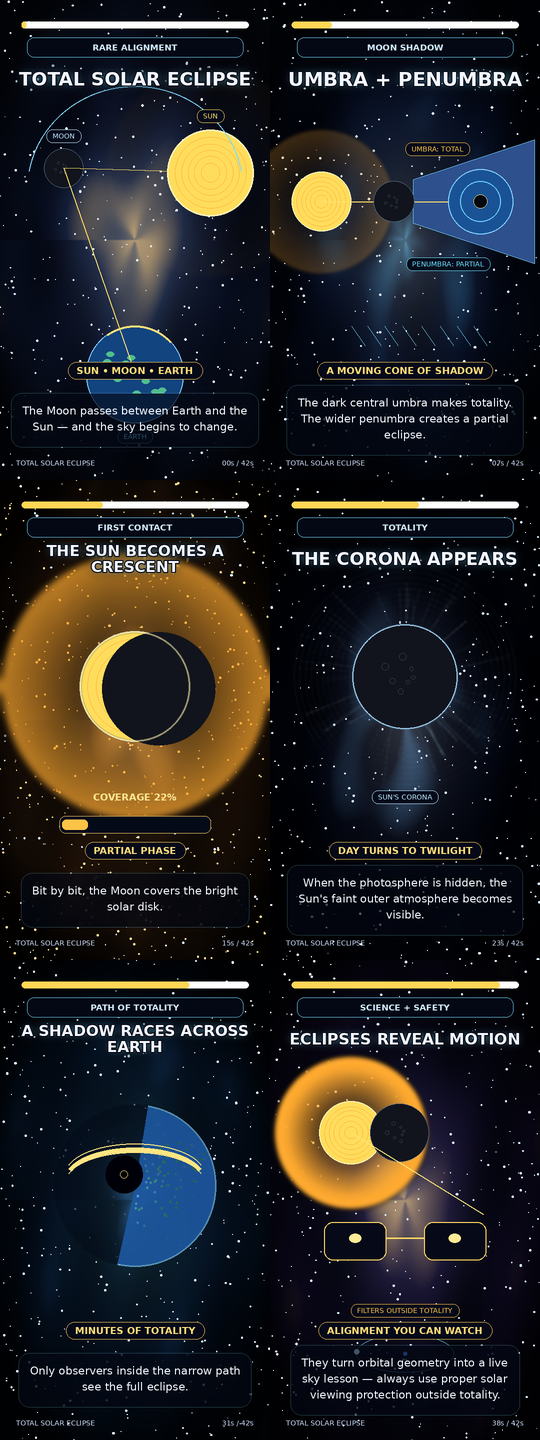

In [5]:
# ==========================
# Render storyboard preview
# ==========================
preview_times = [0.8, 7.4, 15.0, 23.5, 31.0, 38.5]
frames = [Image.fromarray(make_frame(int(t * FPS))) for t in preview_times]
thumb_w = W // 2
thumb_h = H // 2
contact = Image.new("RGB", (thumb_w * 2, thumb_h * 3), (0, 0, 0))
for idx, frame in enumerate(frames):
    thumb = frame.resize((thumb_w, thumb_h), RESAMPLE)
    contact.paste(thumb, ((idx % 2) * thumb_w, (idx // 2) * thumb_h))
contact.save(STORYBOARD_NAME, quality=95)
print(f"Saved storyboard preview: {STORYBOARD_NAME}")
contact


In [6]:
# ==========================
# Render the full vertical video
# ==========================
# Tip: keep DRAFT_MODE=True for testing. Set DRAFT_MODE=False in the config cell for a sharper final export.
writer = imageio.get_writer(
    VIDEO_NAME,
    fps=FPS,
    codec="libx264",
    quality=8 if DRAFT_MODE else 9,
    pixelformat="yuv420p",
    macro_block_size=16,
)

for frame_idx in tqdm(range(NFRAMES), desc="Rendering solar eclipse cinematic short"):
    writer.append_data(make_frame(frame_idx))
writer.close()

print(f"Saved video: {VIDEO_NAME}")
print(f"Duration: {VIDEO_SECONDS:.1f}s | FPS: {FPS} | Size: {W}x{H}")


Rendering solar eclipse cinematic short:   0%|          | 0/840 [00:00<?, ?it/s]

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (540, 960) to (544, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved video: solar_eclipse_cinematic_output/Solar_Eclipse_Cinematic_Info_Shorts.mp4
Duration: 42.0s | FPS: 20 | Size: 540x960


In [ ]:
# Display video inside the notebook, if supported
from IPython.display import Video, display

display(Video(str(VIDEO_NAME), embed=True, html_attributes="controls autoplay loop"))


## Easy ways to customize

Edit only the `SCENES` list in the config cell to change text timing and captions. The visuals are tied to each scene's `kind`, so the video stays cinematic even if you rewrite the script.

Scene kinds available in this notebook:

- `alignment`
- `shadow_geometry`
- `partial_phase`
- `totality`
- `shadow_path`
- `safe_science`

For a stronger Shorts style, keep captions short and punchy. For a documentary style, make the captions longer and set `VIDEO_SECONDS` to 60.
